<a href="https://colab.research.google.com/github/saitejakchintaginjal/AIML-Projects/blob/main/FoodHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
food_order = pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')

In [ ]:
food_order.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24



Observations :
*   Columns include both categorical (restaurant_name, cuisine_type, day_of_the_week, rating) and numerical (cost_of_the_order, food_preparation_time, delivery_time) features.
*   Each row represents a single food order with a unique order_id.
*   Multiple orders can belong to the same restaurant, suggesting repeat transactions.
*   There is a variety of cuisines (Korean, Japanese, Mexican, American, etc.), indicating diverse food options.
*   Orders are categorized into Weekday and Weekend, enabling comparison of ordering behavior across time periods.
*   The rating column includes both numerical ratings (e.g., 3, 4, 5) and "Not given". This indicates a presence of missing feedback and Data cleaning may be required before analysis.



In [ ]:
num_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
cat_cols = ['cuisine_type', 'day_of_the_week', 'rating']

Question 1: How many rows and columns are present in the data?

In [ ]:
food_order.shape

(1898, 9)

Observation :
The dataset contains 1898 rows and 9 columns.

Question 2:What are the datatypes of the different columns in the dataset?

In [ ]:
food_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


Observations:

*   The dataset has 1898 rows and 9 columns with no missing values.
*   The rating column is stored as an object type because it contains values like “Not given”, so it may needs conversion before analysis.
*   There are 5 numerical columns (cost, preparation time, delivery time, IDs) and 4 categorical columns (restaurant, cuisine, day, rating), making it a mix of data types.
*   order_id and customer_id are identifier fields and are not useful for analysis but can be used for grouping or tracking.





Question 3: Are there any missing values in the data? If yes, treat them using an appropriate method.

In [ ]:
food_order.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


Observations :


*   All columns have 0 null values, so the dataset is complete and does not require missing value imputation.



Question 4: Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [ ]:
food_order.describe()


,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


Observations :

*   Cost of the order :
    Average cost : 16.5,
    Median : 14.14 (slightly lower than mean → right-skewed data),
    Range : 4.47 - 35.4 (wide variation in order prices).
    
*   Food preparation time :
    Average : 27.37,
    Median : 27
    Range : 20 - 35 (preparation time looks consistent)

*   Delivery time :
    Average : 24.16,
    Median : 25,
    Range : 15 - 33 (More spread than preparation time → delivery depends on external factors (distance, traffic)
*   Customer ID :  
    Very large range (1311 to 405334) → indicates many unique customers




In [ ]:
food_order['food_preparation_time'].min()

20

In [ ]:
food_order['food_preparation_time'].mean()

np.float64(27.371970495258168)

In [ ]:
food_order['food_preparation_time'].max()

35

Question 5: How many orders are not rated?

In [ ]:
# (food_order['rating']=='Not given').sum()

food_order['rating'].value_counts()['Not given']

np.int64(736)

Observations :


*   There are 736 orders with no rating ("Not given"), which is a significant portion of the dataset.
*   This indicates many customers did not provide feedback, which can impact rating-based analysis.



Question 6: Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.)

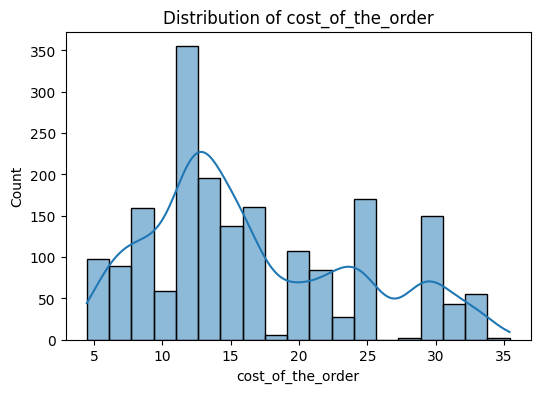

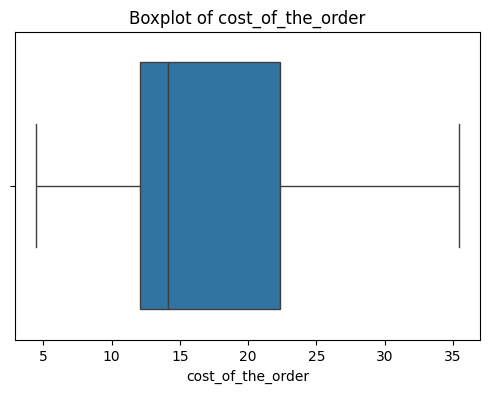

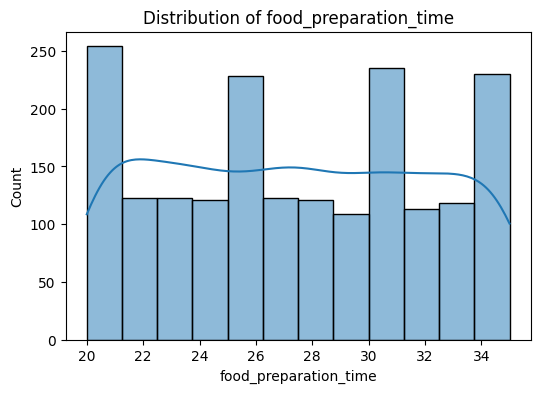

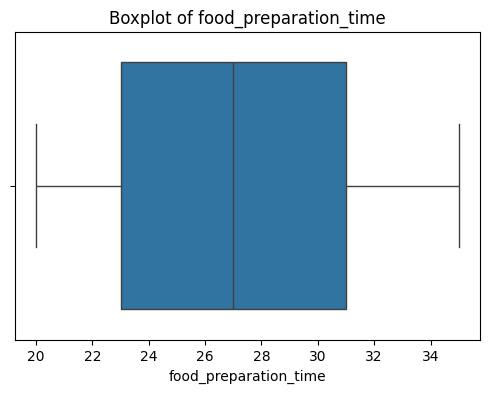

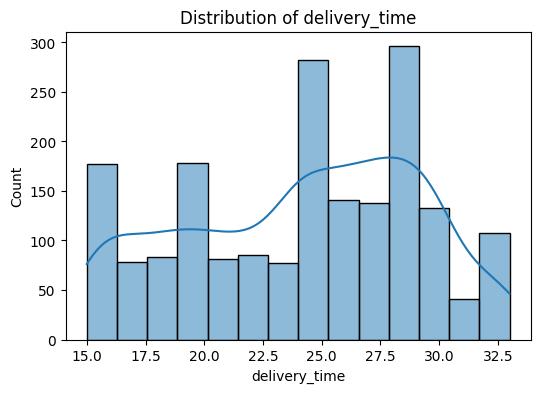

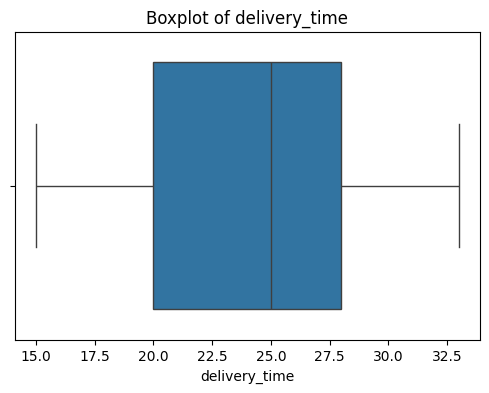

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(food_order[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.figure(figsize=(6,4))
    sns.boxplot(x=food_order[col])
    plt.title(f'Boxplot of {col}')

Observations :

*   Order cost is highly variable and right-skewed. Most of the orders fall in the range of 10-20 rupees. This indicates less expensive orders and majority prefers mid-range pricing.
*   Food preparation time is consistent(25-30 mins), this suggests standardized kitchen processes across restaurants.
*   Delivery time shows moderate variability, this is influenced by external factors like distance and traffic.
*   No significant outliers in any numerical feature.
*   Time-related features are more controlled than cost, as Prep and delivery times are tightly distributed, while cost varies widely.


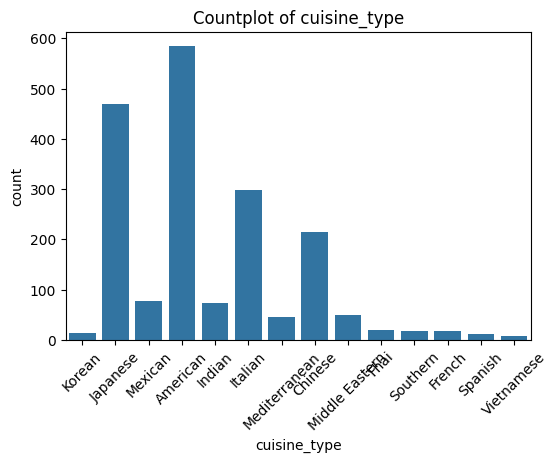

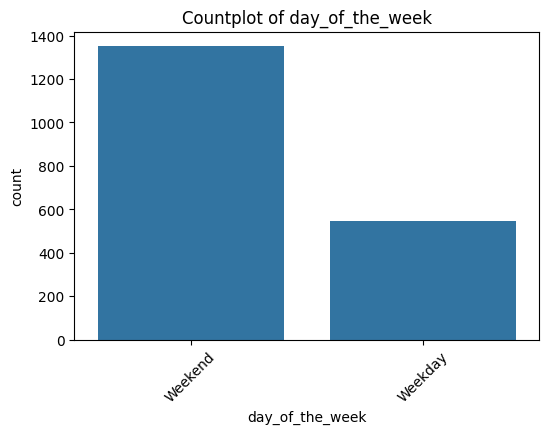

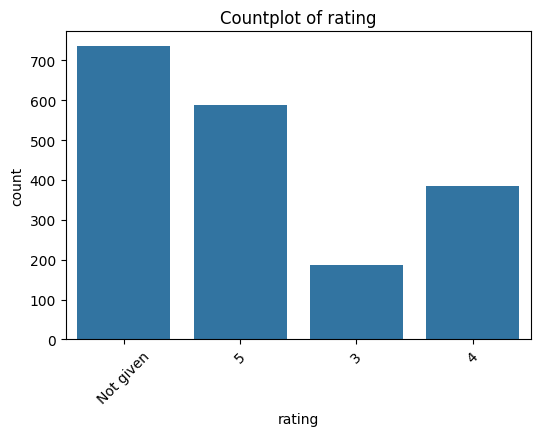

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data = food_order,x=col)
    plt.xticks(rotation=45)
    plt.title(f'Countplot of {col}')

Observations:
*   American, Japanese, Italian and Mediterranean Chinese dominate → most other cuisines have very low participation.
*   Orders are significantly higher on weekends.
*   A large portion of users do not provide ratings.
*   Among available ratings, 5 and 4 dominate, indicating overall good customer satisfaction.





Question 7: Which are the top 5 restaurants in terms of the number of orders received?

In [ ]:
top5 = food_order['restaurant_name'].value_counts().head()
top5

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


Observations :

*   Shake Shack is the top-performing restaurant with 219 orders.
*   Order distribution is skewed, as top 3 restaurants (Shake Shack, The Meatball Shop, Blue Ribbon Sushi) have a large share of total orders.
*   There is a noticeable decline from 1st to 5th rank → indicates uneven popularity among restaurants.







Question 8: Which is the most popular cuisine on weekends?

In [ ]:
weekend_data = food_order[food_order['day_of_the_week']=='Weekend']
weekend_data['cuisine_type'].value_counts().head(1 )

,count
cuisine_type,
American,415


Observations :

*   American cuisine is most popular on weekends with 415 orders.
*   Indicates a strong customer preference for American food during weekends.




Question 9: What percentage of the orders cost more than 20 dollars?

In [ ]:
total_orders = len(food_order)
orders_cost_20dollars = food_order[food_order['cost_of_the_order']>20]
total_orders
orders_cost_20dollars
percentage = (orders_cost_20dollars.shape[0]/total_orders)*100
percentage

29.24130663856691

Observations :

*   Around 29.24% of orders cost more than $20.



Question 10: What is the mean order delivery time?

In [ ]:
food_order['delivery_time'].mean()

np.float64(24.161749209694417)

Observations :

*   The average food delivery time is 24.16 minutes.


Question 11: The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed.

In [ ]:
food_order['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


Observation :

*   Customer 52832 is the most frequent buyer with 13 orders, followed by 47440 (10 orders) and 83287 (9 orders)
*   Targeting these top customers with discount vouchers is effective, as they are more likely to continue ordering and generate repeat business.




Question 12: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)

<Figure size 800x400 with 0 Axes>

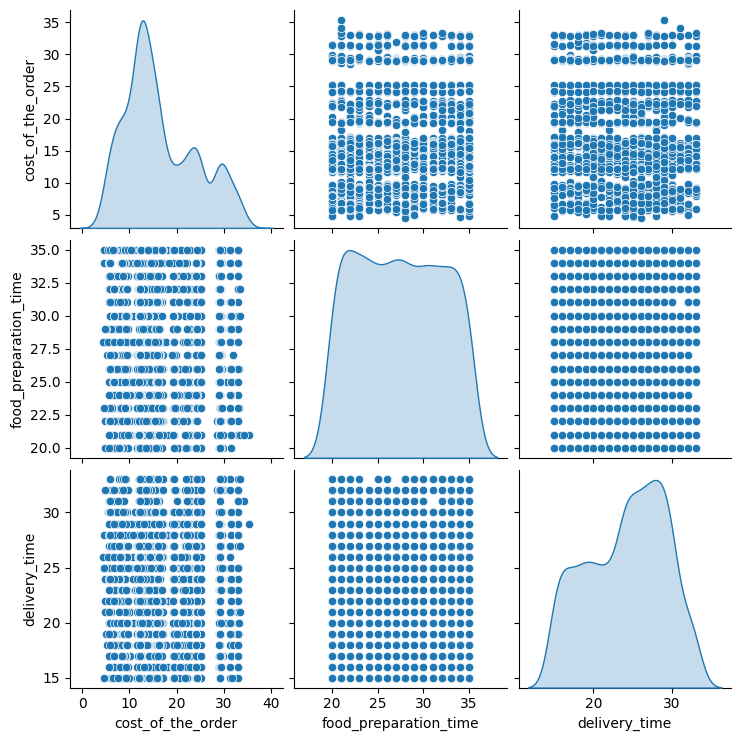

In [ ]:
plt.figure(figsize=(8,4));
sns.pairplot(food_order[num_cols], diag_kind='kde');

Observation :

*   Pair plots show points widely spread → cost, prep time, and delivery time are mostly independent. Very weak correlations between all variables.
*   Cost of the order is right-skewed as most values are in the range 10–20.
*   Food preparation time is evenly distributed.
*   Delivery time is slightly around 25–30 minutes





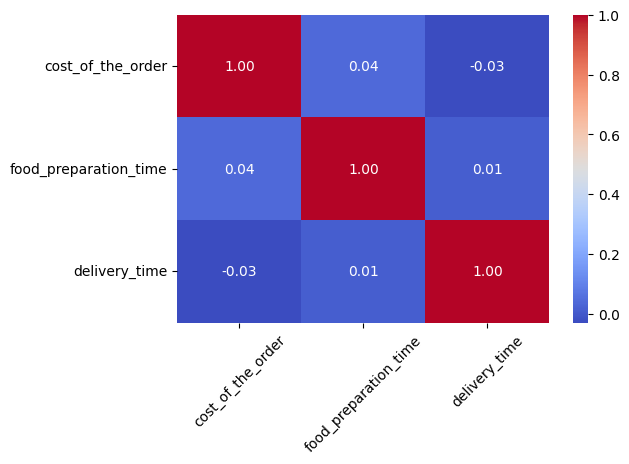

In [ ]:
corr = food_order[num_cols].corr()
plt.figure(figsize=(6,4));
sns.heatmap(corr,cmap='coolwarm',fmt=".2f", annot=True);
plt.xticks(rotation=45);

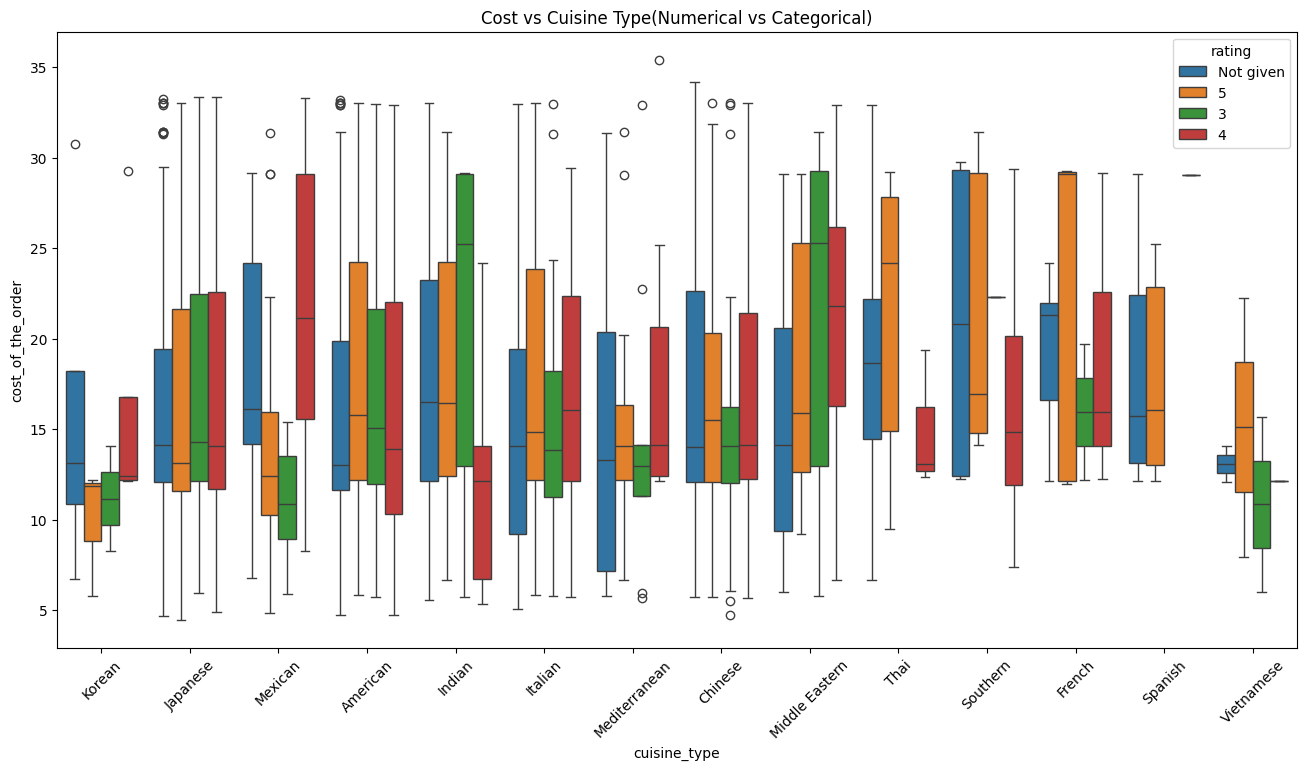

In [ ]:
plt.figure(figsize=(16,8))
sns.boxplot(data=food_order,x='cuisine_type',y='cost_of_the_order',hue='rating');
plt.title('Cost vs Cuisine Type(Numerical vs Categorical)')
plt.xticks(rotation=45);

Observation :

*   Different cuisines have different prices. Some foods (like French, Thai) are generally costlier, while others (like Korean, Vietnamese) are cheaper.
*   Same cuisine can have both cheap and expensive items. Prices vary a lot even within one cuisine, depends on dish or restaurant.
*   Some very expensive orders exist.A few orders are much costlier than others, likely premium dishes.





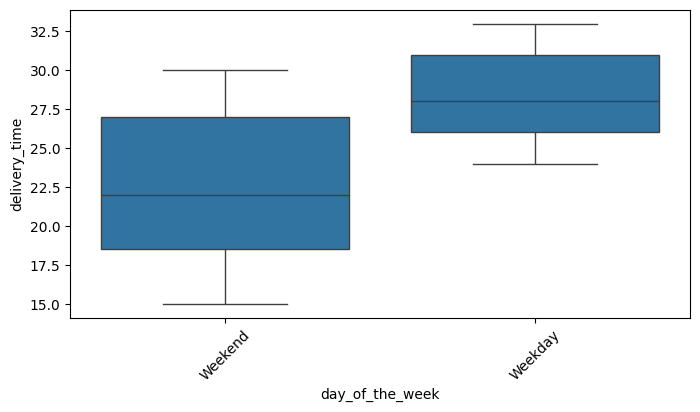

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=food_order,x='day_of_the_week',y='delivery_time');
plt.xticks(rotation=45);

Observations :

*   Delivery is slightly faster on weekends.
*   Weekday deliveries take more time.
*   Delivery times on weekends are more spread out, like sometimes fast, sometimes slow.
*   Weekday deliveries are more consistent, delivery times are more predictable on weekdays.





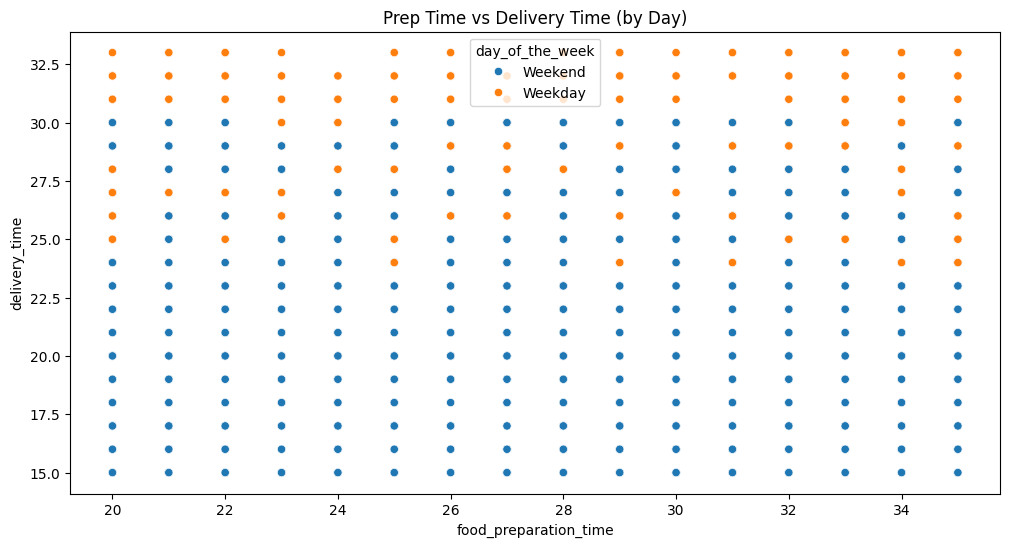

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(data=food_order,
                x='food_preparation_time',
                y='delivery_time',
                hue='day_of_the_week')

plt.title("Prep Time vs Delivery Time (by Day)");


Observations :

*   No strong relationship between prep time and delivery time as Points are scattered and longer cooking time doesn’t always mean longer delivery.
*   Weekdays tend to have slightly higher delivery times.



In [ ]:
avg_cost = food_order.groupby('cuisine_type')['cost_of_the_order'] \
                     .mean() \
                     .sort_values(ascending=False)
avg_cost

,cost_of_the_order
cuisine_type,
French,19.793889
Southern,19.300588
Thai,19.207895
Spanish,18.994167
Middle Eastern,18.820612
Mexican,16.933117
Indian,16.919726
Italian,16.418691
American,16.319829


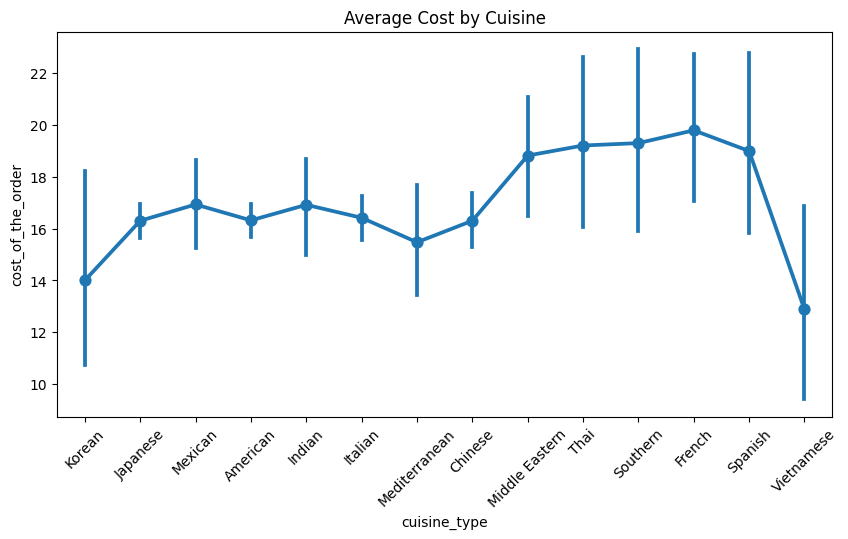

In [ ]:
plt.figure(figsize=(10,5))
sns.pointplot(data=food_order,
              x='cuisine_type',
              y='cost_of_the_order')
plt.xticks(rotation=45)
plt.title("Average Cost by Cuisine")
plt.show()

Observations :

*   French, Thai, Southern and Spanish cuisines are costlier on averag. They have higher average order prices compared to others.
*   Most other cuisines fall in a similar price range. They are moderately priced, around the middle range.
*   Vietnamese and Korean cuisines are cheaper.These have the lowest average cost, making them more budget-friendly.






In [ ]:
food_order.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


Question 13: The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

In [ ]:
food_order.shape

(1898, 9)

In [ ]:
# food_order['rating'] = pd.to_numeric(food_order['rating'], errors='coerce')

# restaurant_stats = food_order.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# filtered_restaurants = restaurant_stats[
#     (restaurant_stats['count'] > 50) & (restaurant_stats['mean'] > 4)
# ]

# filtered_restaurants

# df = food_order.copy()
# df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
# counts = df['restaurant_name'].value_counts()
# average_rating = df.groupby('restaurant_name')['rating'].mean()
# criteria_satisfied = average_rating[(counts > 50) & (average_rating > 4)]
# criteria_satisfied

food_rating = food_order[food_order['rating'] != 'Not given'].copy()
food_rating.loc[:,'rating'] = food_rating['rating'].astype('int')
# food_restaurants = food_rating.groupby('restaurant_name')['rating'].count().sort_values(ascending=False)
counts = food_rating['restaurant_name'].value_counts()
avg_rating = food_rating.groupby('restaurant_name')['rating'].mean()
criteria_satisfied = avg_rating[(counts > 50) & (avg_rating > 4)]
criteria_satisfied


,rating
restaurant_name,
Blue Ribbon Fried Chicken,4.328125
Blue Ribbon Sushi,4.219178
Shake Shack,4.278195
The Meatball Shop,4.511905


Observation :

*   All selected restaurants are both popular and highly rated. They have more than 50 ratings and average rating above 4, showing strong customer trust.
*   The Meatball Shop stands out the most. It has the highest average rating.
*   These restaurants are both popular (many ratings) and highly rated, making them ideal for promotions.







Question 14 : The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [ ]:
# df = food_order.copy()
# df['revenue']=0.0
# df.loc[df['cost_of_the_order']>20, 'revenue'] = df['cost_of_the_order']*0.25;
# df.loc[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20), 'revenue'] = df['cost_of_the_order'] * 0.15
# total_revenue = df['revenue'].sum()
# total_revenue

def rev(value):
  if value > 20:
    return value*0.25
  elif value > 5:
    return value*0.15
  else:
    return 0

food_order['revenue'] = food_order['cost_of_the_order'].apply(rev)
total_revenue = food_order['revenue'].sum()
total_revenue

np.float64(6166.303)

Observations :
*   Total revenue generated is 6166.30.
*   Higher cost orders contribute more revenue. Orders above 20 give 25% commission, so they generate a larger share of revenue.
*   Most orders still contribute via 15% commission. Since many orders are between  5 – 20, they add steady but smaller revenue.
*   Revenue depends on both price and volume







Question 15: The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)

In [ ]:
food_order['total_time'] = food_order['delivery_time'] + food_order['food_preparation_time']
percentage = (food_order['total_time']>60).mean()*100
percentage

np.float64(10.537407797681771)

Observations :

*   Only approx 10.5% of orders take more than 60 minutes.
*   Almost 90% of orders are delivered within 1 hour.
*   Long delivery time happens rarely.When it happens, it is likely due to combined delays in preparation + delivery.





Question 16: The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [ ]:
food_order.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
avg_delivery = food_order.groupby('day_of_the_week')['delivery_time'].mean();
avg_delivery

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


Observation :

*   Delivery time is slightly higher on weekdays. Orders take a bit more time compared to weekends.
*   Weekend deliveries are slightly faster. Possibly due to better availability of delivery agents or different traffic patterns.
*   Difference is not very large. Both weekday and weekend delivery times are quite similar overall.





Text(0.5, 1.0, 'Cuisine Type vs Day of the Week')

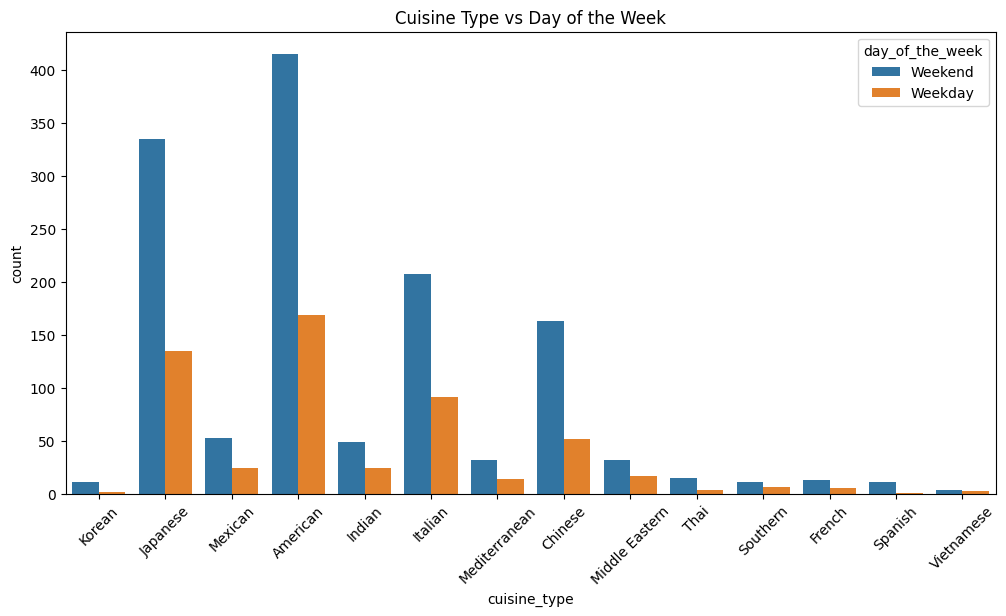

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(data=food_order, x='cuisine_type', hue='day_of_the_week')
plt.xticks(rotation=45)
plt.title("Cuisine Type vs Day of the Week")

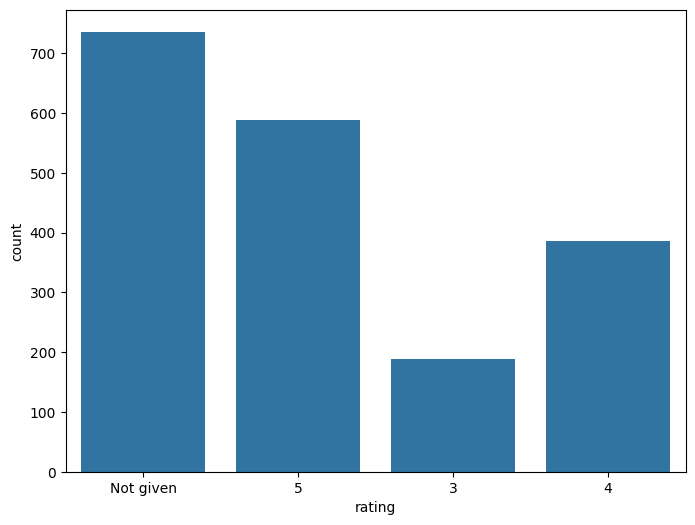

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(data=food_order, x='rating');

In [ ]:
food_order['restaurant_name'].value_counts()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


Question 17: What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.)

Observation :

*   Majority orders are mid-priced. Most customers prefer affordable meals (< $20).
*   American cuisine dominates demand.Highest number of orders, especially on weekends.
*   Few cuisines have very low demand. Some cuisines (French, Spanish, Vietnamese) are rarely ordered.
*   Customer ratings are generally positive. Most ratings are 4 and 5, but many users don’t give ratings.
*   Delivery system is efficient. Most (approx 90%) of orders are delivered within 60 minutes.
*   As per data top restaurants(Shake Shack, Blue Ribbon, etc.) contribute more in driving business.








Recommendations :

*   Promote high-performing restaurants. Feature top-rated + high-order restaurants in ads to increase conversions.
*   Focus on American cuisine during weekends. Run targeted promotions or discounts to maximize peak demand.
*   Encourage more customer ratings. Offer small incentives (discounts/coupons) to reduce “Not given” feedback.
*   Loyalty programs for repeat customers. Reward frequent users with exclusive offers or membership benefits.
*   Introduce premium offerings. Since approx 30% orders are high-value, create combo deals or premium menus.
*   Optimize weekday delivery performance. Slight delays on weekdays, improve logistics or staffing.
*   Expand popular cuisines. Increase availability of high-demand cuisines (American, Japanese, Italian).





